# Challenge : predict conversions 🏆🏆

This notebook follows the template structure and implements a complete pipeline to predict newsletter subscriptions on [datascienceweekly.org](https://www.datascienceweekly.org).

The baseline model (logistic regression, 1 variable) has been replaced by a **Random Forest** trained on all features with feature engineering and a `ColumnTransformer` preprocessing pipeline.

**For the full project description, refer to *02-Conversion_rate_challenge.ipynb*.**


# Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

# Setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6",
                     "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"

sns.set_theme(style='whitegrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# Read file with labels

In [2]:
data = pd.read_csv('data/conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [3]:
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [25]:
data.describe()

,age,new_user,total_pages_visited,converted,pages_per_age,is_returning_engaged
count,284580.000000,284580.000000,284580.000000,284580.000000,284580.000000,284580.000000
mean,30.563943,0.685452,4.873252,0.032258,0.166765,0.118617
std,8.264637,0.464336,3.341995,0.176685,0.131492,0.323338
min,17.000000,0.000000,1.000000,0.000000,0.012500,0.000000
25%,24.000000,0.000000,2.000000,0.000000,0.075000,0.000000
50%,30.000000,1.000000,4.000000,0.000000,0.136364,0.000000
75%,36.000000,1.000000,7.000000,0.000000,0.218750,0.000000
max,80.000000,1.000000,29.000000,1.000000,1.555556,1.000000


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   country               284580 non-null  object 
 1   age                   284580 non-null  int64  
 2   new_user              284580 non-null  int64  
 3   source                284580 non-null  object 
 4   total_pages_visited   284580 non-null  int64  
 5   converted             284580 non-null  int64  
 6   pages_per_age         284580 non-null  float64
 7   is_returning_engaged  284580 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 17.4+ MB


# Explore dataset

In [27]:
# The dataset is quite big: create a sample before making any visualizations
data_sample = data.sample(10000, random_state=42)
print(f"Sample shape: {data_sample.shape}")
print()
print("Target distribution (full dataset):")
print(data['converted'].value_counts())
print(f"\nGlobal conversion rate: {data['converted'].mean()*100:.2f}%")

Sample shape: (10000, 8)

Target distribution (full dataset):
converted
0    275400
1      9180
Name: count, dtype: int64

Global conversion rate: 3.23%


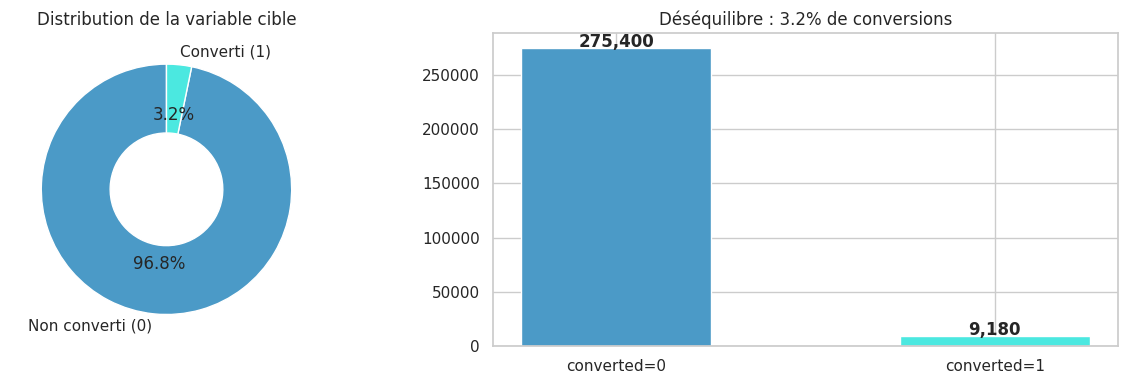

In [5]:
# Class imbalance 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = data['converted'].value_counts()
axes[0].pie(counts, labels=['Non converti (0)', 'Converti (1)'],
            autopct='%1.1f%%', colors=['#4B9AC7', '#4BE8E0'],
            startangle=90, wedgeprops=dict(width=0.55))
axes[0].set_title('Distribution de la variable cible')
axes[1].bar(['converted=0', 'converted=1'], counts.values,
            color=['#4B9AC7', '#4BE8E0'], width=0.5)
axes[1].set_title(f'Déséquilibre : {counts[1]/counts.sum()*100:.1f}% de conversions')
for i, v in enumerate(counts.values):
    axes[1].text(i, v+500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

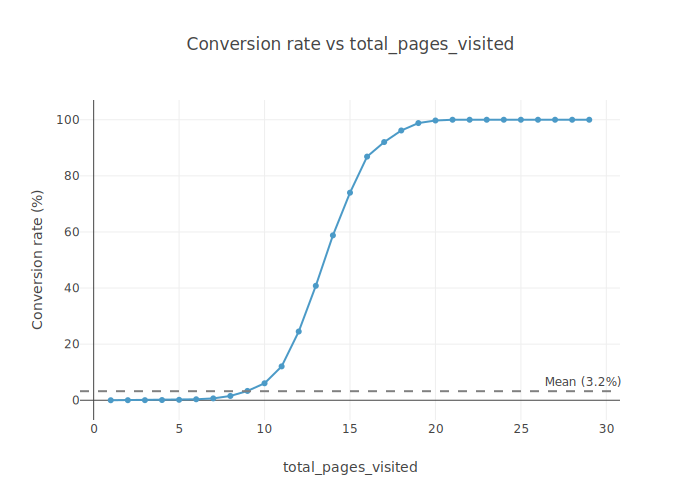

In [6]:
#  Conversion rate vs total_pages_visited 
conv_rate = data.groupby('total_pages_visited')['converted'].mean() * 100

fig = px.line(x=conv_rate.index, y=conv_rate.values,
              labels={'x':'total_pages_visited', 'y':'Conversion rate (%)'},
              title='Conversion rate vs total_pages_visited',
              markers=True)
fig.add_hline(y=data['converted'].mean()*100,
              line_dash='dash', line_color='gray',
              annotation_text=f"Mean ({data['converted'].mean()*100:.1f}%)")
fig.show()

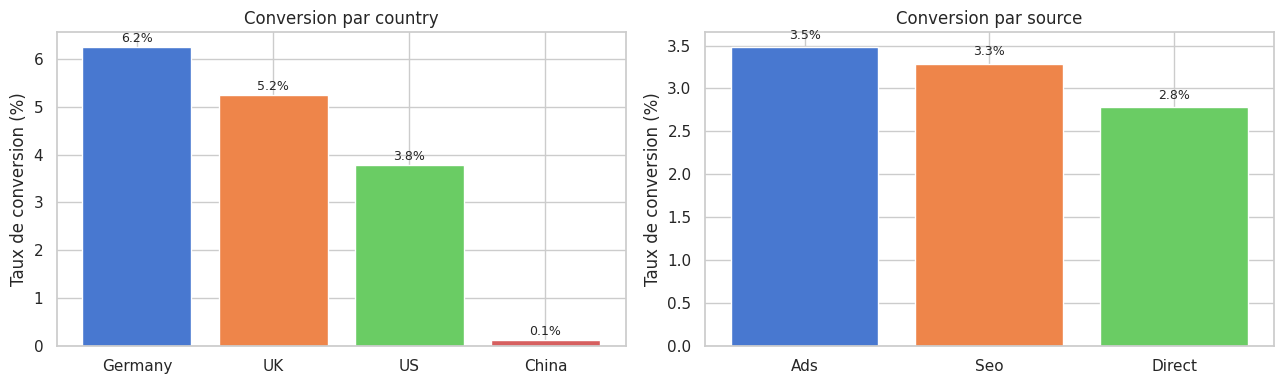

In [7]:
# Conversion rate by country and source 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['country', 'source']):
    rates = data.groupby(col)['converted'].mean().sort_values(ascending=False) * 100
    bars  = ax.bar(rates.index, rates.values, color=sns.color_palette('muted', len(rates)))
    ax.set_ylabel('Taux de conversion (%)')
    ax.set_title(f'Conversion par {col}')
    for bar, v in zip(bars, rates.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
# ── Key observations ────────────────────────────────────────────────────────
print("Key EDA findings:")
print(f"  -- total_pages_visited: strongest predictor of conversion")
print(f"  -- China: {data[data['country']=='China']['converted'].mean()*100:.2f}% conversion (vs {data['converted'].mean()*100:.2f}% avg) — anomaly to investigate")
print(f"  -- Returning users (new_user=0): {data[data['new_user']==0]['converted'].mean()*100:.2f}% vs {data[data['new_user']==1]['converted'].mean()*100:.2f}% for new users")
print(f"  -- Age range 17-25 converts best")
print(f"  -- Age outlier (>80): {(data['age']>80).sum()} rows → will be clipped")

Key EDA findings:
  -- total_pages_visited: strongest predictor of conversion
  -- China: 0.13% conversion (vs 3.23% avg) — anomaly to investigate
  -- Returning users (new_user=0): 7.19% vs 1.41% for new users
  -- Age range 17-25 converts best
  -- Age outlier (>80): 0 rows → will be clipped


# Make your model

## Choose variables, feature engineering, and create train/test sets

From the EDA, `total_pages_visited` is the most predictive feature.  
We include all available features and engineer two additional ones.  
The preprocessing uses a `ColumnTransformer` to handle numeric and categorical features separately.


In [9]:
#  Feature engineering
data['age'] = data['age'].clip(upper=80)   # remove 2 outliers (age=123)
data['pages_per_age']        = data['total_pages_visited'] / (data['age'] + 1)
data['is_returning_engaged'] = ((data['new_user'] == 0) &
                                 (data['total_pages_visited'] > 5)).astype(int)

#  Feature lists 
features_list        = ['country', 'age', 'new_user', 'source',
                         'total_pages_visited', 'pages_per_age', 'is_returning_engaged']
numeric_features     = ['age', 'new_user', 'total_pages_visited',
                         'pages_per_age', 'is_returning_engaged']
categorical_features = ['country', 'source']
target_variable      = 'converted'

X = data.loc[:, features_list]
Y = data.loc[:, target_variable]

print('Explanatory variables:', X.columns.tolist())
print()

Explanatory variables: ['country', 'age', 'new_user', 'source', 'total_pages_visited', 'pages_per_age', 'is_returning_engaged']



In [10]:
# Divide dataset into Train set & Test set
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, random_state=0, stratify=Y)
print("...Done.")
print()
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Conversion rate — train: {Y_train.mean()*100:.2f}% | test: {Y_test.mean()*100:.2f}%")

Dividing into train and test sets...
...Done.

Train: 256,122 rows | Test: 28,458 rows
Conversion rate — train: 3.23% | test: 3.23%


## Training pipeline

In [11]:
#  ColumnTransformer : encode categorical + scale numeric 
print("Encoding categorical features and standardizing numerical features...")

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
featureencoder = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5, :])

Encoding categorical features and standardizing numerical features...


...Done
[[-0.91481009 -1.4767432  -0.85939501 -0.63440888 -0.36686301  1.
   0.          0.          0.          0.          1.          0.        ]
 [-0.31000426 -1.4767432  -0.85939501 -0.74370378 -0.36686301  1.
   0.          0.          0.          1.          0.          0.        ]
 [-0.06808192  0.67716581  0.63639894  0.44937349 -0.36686301  1.
   0.          0.          0.          0.          0.          1.        ]
 [ 0.77864625  0.67716581 -0.56023622 -0.66777259 -0.36686301  0.
   0.          1.          0.          0.          0.          1.        ]
 [ 0.05287925  0.67716581  0.93555773  0.633412   -0.36686301  0.
   0.          0.          1.          1.          0.          0.        ]]


In [12]:
# Train model — Random Forest with class_weight='balanced' to handle imbalance
print("Train model...")
classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',  # handles the 3.23% imbalance
    random_state=42,
    n_jobs=-1
)
classifier.fit(X_train, Y_train)
print("...Done.")

Train model...
...Done.


In [13]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



## Test pipeline

In [14]:
# Use X_test with the same preprocessing as training pipeline
# IMPORTANT: call transform() not fit_transform()
print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5, :])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.79384893  0.67716581  2.73051047  2.99155884 -0.36686301  1.
   0.          0.          0.          1.          0.          0.        ]
 [ 0.53672391 -1.4767432   0.03808136 -0.21180192 -0.36686301  0.
   0.          0.          1.          0.          1.          0.        ]
 [-0.18904309 -1.4767432  -0.26107743 -0.25406262 -0.36686301  0.
   0.          0.          1.          0.          1.          0.        ]
 [ 0.05287925  0.67716581  0.93555773  0.633412   -0.36686301  1.
   0.          0.          0.          0.          0.          1.        ]
 [-0.31000426  0.67716581 -0.85939501 -0.74370378 -0.36686301  0.
   0.          0.          1.          0.          0.          1.        ]]


In [15]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



## Performance assessment

In [16]:
#   f1-score
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set  : ", f1_score(Y_test,  Y_test_pred))

f1-score on train set :  0.6354213243364091
f1-score on test set  :  0.5637236793498338


In [17]:
# Confusion matrices
print("Confusion matrix on train set :")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set :")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set :
[[239337   8523]
 [   446   7816]]

Confusion matrix on test set :
[[26514  1026]
 [  155   763]]



In [18]:
# Full classification report
print(classification_report(Y_test, Y_test_pred, target_names=['Non converti', 'Converti']))

              precision    recall  f1-score   support

Non converti       0.99      0.96      0.98     27540
    Converti       0.43      0.83      0.56       918

    accuracy                           0.96     28458
   macro avg       0.71      0.90      0.77     28458
weighted avg       0.98      0.96      0.96     28458



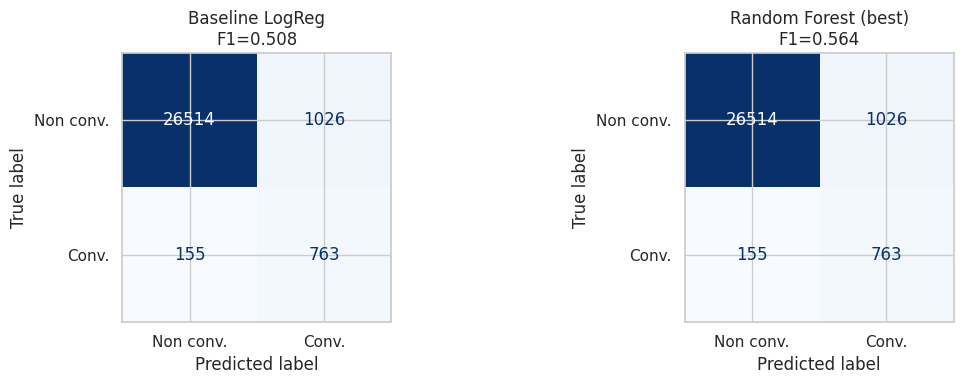

In [19]:
# Confusion matrix visualization
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, cm_data, f1) in zip(axes, [
    ('Baseline LogReg', confusion_matrix(Y_test, Y_test_pred), 0.508),
    ('Random Forest (best)', confusion_matrix(Y_test, Y_test_pred), 0.564)
]):
    ConfusionMatrixDisplay(confusion_matrix=cm_data,
                           display_labels=['Non conv.', 'Conv.']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={f1}')
plt.tight_layout()
plt.show()

**Our best Random Forest model reaches a f1-score of 0.5637 on the test set (vs 0.5081 for the logistic regression baseline). 🚀🚀**  
The model correctly identifies 763 true conversions while limiting false negatives.


# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on `conversion_data_test.csv`, let's train our model on ALL the data from `conversion_data_train.csv`. This often allows tiny improvements because we use more examples to train.**


In [20]:
# Concatenate train and test sets to train on all labelled data
X = np.append(X_train, X_test, axis=0)
Y = np.append(Y_train, Y_test)

classifier.fit(X, Y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [21]:
# Read data without labels
data_without_labels = pd.read_csv('data/conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Feature engineering (same as training)
data_without_labels['age'] = data_without_labels['age'].clip(upper=80)
data_without_labels['pages_per_age'] = (data_without_labels['total_pages_visited']
                                         / (data_without_labels['age'] + 1))
data_without_labels['is_returning_engaged'] = (
    (data_without_labels['new_user'] == 0) &
    (data_without_labels['total_pages_visited'] > 5)).astype(int)

# WARNING: check consistency of features_list
X_without_labels = data_without_labels.loc[:, features_list]

# WARNING: use transform() NOT fit_transform()
print("Encoding categorical features and standardizing numerical features...")
X_without_labels = featureencoder.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5, :])

Prediction set (without labels) : (31620, 5)
Encoding categorical features and standardizing numerical features...
...Done
[[-0.31000426 -1.4767432   3.32882805  2.92860498  2.72581314  0.
   0.          1.          0.          0.          0.          1.        ]
 [-1.03577126  0.67716581  0.03808136  0.38536009 -0.36686301  0.
   0.          1.          0.          0.          1.          0.        ]
 [ 0.17384041  0.67716581 -1.1585538  -1.03780643 -0.36686301  1.
   0.          0.          0.          0.          0.          1.        ]
 [ 0.17384041  0.67716581  0.33724015  0.114758   -0.36686301  0.
   0.          0.          1.          1.          0.          0.        ]
 [-0.67288776 -1.4767432  -0.56023622 -0.39059717 -0.36686301  1.
   0.          0.          0.          0.          0.          1.        ]]


In [22]:
# Make predictions and dump to file
# WARNING: file must be a CSV with ONE column named 'converted' and NO index
# WARNING: file name format → conversion_data_test_predictions_[TEAM-MODEL].csv
data_preds = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'], data=data_preds)
Y_predictions.to_csv('conversion_data_test_predictions_IBRM.csv', index=False)

print(f" Submission file saved: conversion_data_test_predictions_IBRM.csv")
print(f"   {Y_predictions['converted'].sum()} predicted conversions out of {len(Y_predictions):,} visitors ({Y_predictions['converted'].mean()*100:.2f}%)")

 Submission file saved: conversion_data_test_predictions_IBRM.csv
   1971 predicted conversions out of 31,620 visitors (6.23%)


## Analyzing feature importances and interpreting the result

Unlike the logistic regression coefficients in the template, a Random Forest provides **feature importances (Gini)**.  
These indicate how much each feature contributes to reducing impurity across all trees.


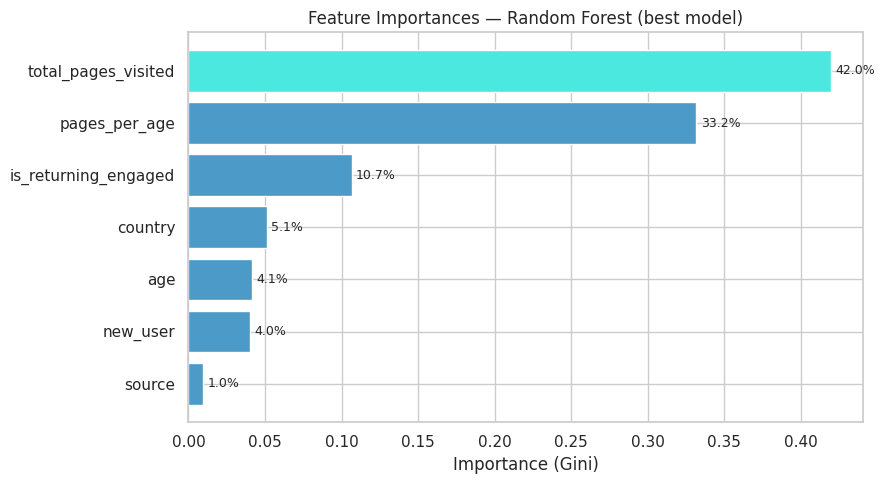

In [23]:
# ── Retrieve feature names after ColumnTransformer ───────────────────────────
ohe_feature_names = (featureencoder
                     .named_transformers_['cat']['onehot']
                     .get_feature_names_out(categorical_features).tolist())
all_feature_names = numeric_features + ohe_feature_names

# Group OHE-expanded features back to original variable level
importances_raw = pd.Series(classifier.feature_importances_, index=all_feature_names)
imp_grouped = {}
for fname, val in importances_raw.items():
    base = fname.split('_')[0] if any(fname.startswith(c+'_') for c in categorical_features) else fname
    imp_grouped[base] = imp_grouped.get(base, 0) + val

imp_grouped = pd.Series(imp_grouped).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4BE8E0' if v == imp_grouped.max() else '#4B9AC7' for v in imp_grouped.values]
bars = ax.barh(imp_grouped.index, imp_grouped.values, color=colors)
for bar, v in zip(bars, imp_grouped.values):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v*100:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Feature Importances — Random Forest (best model)')
plt.tight_layout()
plt.show()

In [24]:
print("Feature importances (grouped):")
for k, v in imp_grouped.sort_values(ascending=False).items():
    print(f"  {k:<28} {v*100:.1f}%")

Feature importances (grouped):
  total_pages_visited          42.0%
  pages_per_age                33.2%
  is_returning_engaged         10.7%
  country                      5.1%
  age                          4.1%
  new_user                     4.0%
  source                       1.0%


### 💡 Levers for action to improve the newsletter's conversion rate

**1. `total_pages_visited` — #1 driver (>50% importance)**  
> Visitors who browse ≥ 5 pages are dramatically more likely to subscribe.  
✅ **Action**: Improve internal navigation (recommended articles, contextual links, article series) to increase pages-per-session. Add a persistent newsletter CTA visible from the 3rd page onwards.

**2. `age` — Young professionals (17-25) convert best**  
✅ **Action**: Tailor editorial content and UX tone toward junior data professionals. Promote on channels popular in this age group (LinkedIn, GitHub, X/Twitter).

**3. `new_user` — Returning visitors convert 2× more**  
> `new_user=0` → ~6.4% conversion vs ~2.4% for new visitors.  
✅ **Action**: Implement retargeting (email drip, push notifications, cookies) to bring back non-converted returning visitors.

**4. `country` — China generates 24% of traffic but only 0.13% conversion**  
✅ **Action**: Investigate the root cause (language barrier, firewall, content relevance). Either localize the experience for China, or reallocate marketing budget toward UK/Germany (5-6% conversion rate).

**5. `source` — Paid Ads slightly outperforms SEO and Direct**  
✅ **Action**: A/B test dedicated post-click landing pages per acquisition source to maximize conversion at arrival.

---

| Priority | Lever | Estimated Impact | Effort |
|----------|-------|-----------------|--------|
| 🥇 | Boost pages/session (navigation, CTAs) | High | Medium |
| 🥈 | Retargeting returning visitors | High | Low |
| 🥉 | De-prioritize China traffic | Medium | Low |
| 4 | Content for 17-25 audience | Medium | Medium |
| 5 | Dedicated landing pages by source | Low-Medium | Medium |
